In [ ]:
!pip install ultralytics

In [ ]:
from huggingface_hub import login
login()


In [ ]:
from huggingface_hub import snapshot_download

dataset_path = snapshot_download(repo_id="RahulAloth/crf-dataset", repo_type="dataset")
dataset_path

In [ ]:
import os

dataset_abs_path = '/root/.cache/huggingface/hub/datasets--RahulAloth--crf-dataset/snapshots/88a277ee28938e92515994029535cb9821f02475'

print(f"Listing contents of the root dataset directory: {dataset_abs_path}/")
!ls -F {dataset_abs_path}/

In [ ]:
import os

dataset_abs_path = '/root/.cache/huggingface/hub/datasets--RahulAloth--crf-dataset/snapshots/88a277ee28938e92515994029535cb9821f02475'

print(f"Listing contents of {dataset_abs_path}/crf_train/ recursively:")
!ls -R {dataset_abs_path}/crf_train/

print(f"\nListing contents of {dataset_abs_path}/crf_val/ recursively:")
!ls -R {dataset_abs_path}/crf_val/

In [ ]:
import json
import os

dataset_abs_path = '/root/.cache/huggingface/hub/datasets--RahulAloth--crf-dataset/snapshots/88a277ee28938e92515994029535cb9821f02475'

# Path to the train.json file
train_json_path = os.path.join(dataset_abs_path, 'crf_train', 'train.json')

print(f"Reading contents of: {train_json_path}")

# Read and display the first few lines or a sample of the JSON file
try:
    with open(train_json_path, 'r') as f:
        train_data = json.load(f)
    print("Successfully loaded train.json.")
    # Print a summary or the first few items to understand its structure
    if isinstance(train_data, list) and len(train_data) > 0:
        print(f"Number of entries in train.json: {len(train_data)}")
        print("First entry sample:")
        print(json.dumps(train_data[0], indent=2))
    elif isinstance(train_data, dict):
        print(f"Keys in train.json: {train_data.keys()}")
        # If it's a dict, maybe it has a 'data' key or similar
        if 'annotations' in train_data and isinstance(train_data['annotations'], list):
            print(f"Number of annotations: {len(train_data['annotations'])}")
            if len(train_data['annotations']) > 0:
                print("First annotation sample:")
                print(json.dumps(train_data['annotations'][0], indent=2))
        else:
            # Print entire dict if small, or a subset
            print(json.dumps(train_data, indent=2))
    else:
        print("Unknown JSON structure.")
except FileNotFoundError:
    print(f"Error: {train_json_path} not found.")
except json.JSONDecodeError:
    print(f"Error: Could not decode JSON from {train_json_path}.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

In [ ]:
import json
import os
from PIL import Image

# Ensure this path explicitly points to the new, reliable dataset location
dataset_abs_path = '/content/crf-dataset-fresh'

def convert_coco_to_yolo(split):
    print(f"\nConverting {split} annotations from COCO to YOLO format...")
    json_path = os.path.join(dataset_abs_path, f'crf_{split}', f'{split}.json')
    images_dir = os.path.join(dataset_abs_path, f'crf_{split}', 'images')
    labels_dir = os.path.join(dataset_abs_path, f'crf_{split}', 'labels')

    os.makedirs(labels_dir, exist_ok=True)

    with open(json_path, 'r') as f:
        data = json.load(f)

    images_metadata = {img['id']: {'file_name': img['file_name'], 'width': img['width'], 'height': img['height']} for img in data['images']}
    categories = {cat['id']: cat['name'] for cat in data['categories']}

    # The category IDs in the dataset are 1-indexed. YOLO expects 0-indexed.
    # We need to map them to 0 and 1, based on the `data.yaml` names.
    # From inspection of previous output, category ID 1 is 'section_header' and ID 2 is 'sdtm_box'.
    # We will map 'section_header' to YOLO class 0 (header) and 'sdtm_box' to YOLO class 1 (field).
    class_mapping = {
        # Map original category ID to YOLO class ID
        1: 0, # 'section_header' -> header (class 0)
        2: 1  # 'sdtm_box' -> field (class 1)
    }

    for ann in data['annotations']:
        image_id = ann['image_id']
        category_id = ann['category_id']

        if image_id not in images_metadata:
            print(f"Warning: Image ID {image_id} not found in metadata. Skipping annotation.")
            continue

        if category_id not in class_mapping:
            # This warning should ideally not appear now if all relevant categories are mapped
            print(f"Warning: Category ID {category_id} not mapped to a YOLO class. Skipping annotation.")
            continue

        img_meta = images_metadata[image_id]
        img_width = img_meta['width']
        img_height = img_meta['height']
        img_file_name = img_meta['file_name']

        # COCO bbox: [x_top_left, y_top_left, width, height]
        # YOLO bbox: [class_id x_center y_center width height] (normalized)
        x_tl, y_tl, bbox_width, bbox_height = ann['bbox']

        # Calculate center coordinates
        x_center = (x_tl + bbox_width / 2) / img_width
        y_center = (y_tl + bbox_height / 2) / img_height

        # Normalize width and height
        normalized_width = bbox_width / img_width
        normalized_height = bbox_height / img_height

        # Get YOLO class ID
        yolo_class_id = class_mapping[category_id]

        label_file_name = os.path.splitext(img_file_name)[0] + '.txt'
        label_file_path = os.path.join(labels_dir, label_file_name)

        # Append to file as there might be multiple annotations per image
        with open(label_file_path, 'a') as f:
            f.write(f"{yolo_class_id} {x_center:.6f} {y_center:.6f} {normalized_width:.6f} {normalized_height:.6f}\n")

    print(f"Conversion complete for {split} split. Labels saved to {labels_dir}")

# Run conversion for both train and val splits
convert_coco_to_yolo('train')
convert_coco_to_yolo('val')

print("\nVerifying created label files...")
# Verify by listing some created label files
print(f"Listing first 5 label files in {os.path.join(dataset_abs_path, 'crf_train', 'labels')}:")
!ls {os.path.join(dataset_abs_path, 'crf_train', 'labels')} | head -n 5
print(f"Listing first 5 label files in {os.path.join(dataset_abs_path, 'crf_val', 'labels')}:")
!ls {os.path.join(dataset_abs_path, 'crf_val', 'labels')} | head -n 5

# Also inspect the first created label file to check content
train_labels_path = os.path.join(dataset_abs_path, 'crf_train', 'labels')
first_train_label_file = next(iter(os.listdir(train_labels_path)), None)
if first_train_label_file:
    print(f"\nContent of first train label file ({first_train_label_file}):")
    with open(os.path.join(train_labels_path, first_train_label_file), 'r') as f:
        print(f.read())
else:
    print("No label files found in train set.")

In [ ]:
import os
from ultralytics import YOLO
from huggingface_hub import snapshot_download
import shutil

# --- Step 1: Re-download the dataset to a predictable location in /content/ ---
# This ensures the dataset is accessible within the current runtime,
# bypassing potential issues with the HuggingFace cache directory's path resolution.
print("Re-downloading dataset to /content/crf-dataset-fresh for reliable access...")
downloaded_cache_path = snapshot_download(repo_id="RahulAloth/crf-dataset", repo_type="dataset")

new_dataset_base_path = '/content/crf-dataset-fresh'
# Clean up previous attempts if any
if os.path.exists(new_dataset_base_path):
    print(f"Removing existing directory: {new_dataset_base_path}")
    shutil.rmtree(new_dataset_base_path)
# Copy the entire downloaded content from the cache to the new reliable location
print(f"Copying dataset from cache '{downloaded_cache_path}' to '{new_dataset_base_path}'")
shutil.copytree(downloaded_cache_path, new_dataset_base_path)
print(f"Dataset successfully moved from cache to: {new_dataset_base_path}")

# --- Step 2: Define paths based on the new reliable location ---
# Now use new_dataset_base_path as the base for all dataset operations.
# These are the parent directories that will contain 'images' and 'labels' subdirectories.
train_dir_for_yaml = os.path.join(new_dataset_base_path, 'crf_train')
val_dir_for_yaml = os.path.join(new_dataset_base_path, 'crf_val')

# --- Step 3: Ensure the labels are in YOLO format ---
# This part assumes the COCO to YOLO conversion script (from a previous cell) has been executed.
# If not, that cell needs to be run before this one to create the 'labels' directories and .txt files.
# We assume 'crf_train/labels' and 'crf_val/labels' are now populated with YOLO .txt files.

# Define the content of data.yaml
yaml_content_corrected = f"""
train: {train_dir_for_yaml}
val: {val_dir_for_yaml}

names:
  0: header
  1: field
"""

# Write the corrected content to data.yaml
yaml_file_path = "data.yaml"
with open(yaml_file_path, "w") as f:
    f.write(yaml_content_corrected)

print(f"Rewrote {yaml_file_path} at: {os.path.abspath(yaml_file_path)} with corrected paths: train={train_dir_for_yaml}, val={val_dir_for_yaml}")

# --- Step 4: Train the YOLO model ---
model = YOLO("yolov8n.pt")  # nano model for speed

print("\nStarting YOLOv8 model training...")
model.train(
    data="/content/data.yaml",  # Point to the newly created data.yaml
    epochs=50,
    imgsz=1024,
    batch=4,
    workers=2,
    device=0  # GPU
)

Visualizing Training Results

Ultralytics automatically saves various plots during training, which provide insights into the model's performance and training progress. Let's display some of them.

In [ ]:
from IPython.display import Image, display
import os

# The training results are saved in the 'runs/detect/train-8' directory
results_dir = '/content/runs/detect/train-8'

print(f"Displaying key plots from: {results_dir}")

# Display the overall results plot
results_plot_path = os.path.join(results_dir, 'results.png')
if os.path.exists(results_plot_path):
    print("\n--- Overall Training Results (Precision, Recall, mAP over epochs) ---")
    display(Image(filename=results_plot_path))
else:
    print(f"Results plot not found at: {results_plot_path}")

# Display the F1-Confidence curve
f1_curve_path = os.path.join(results_dir, 'F1_curve.png')
if os.path.exists(f1_curve_path):
    print("\n--- F1-Confidence Curve ---")
    display(Image(filename=f1_curve_path))
else:
    print(f"F1-Confidence curve not found at: {f1_curve_path}")

# Display the P-Confidence curve
p_curve_path = os.path.join(results_dir, 'P_curve.png')
if os.path.exists(p_curve_path):
    print("\n--- Precision-Confidence Curve ---")
    display(Image(filename=p_curve_path))
else:
    print(f"Precision-Confidence curve not found at: {p_curve_path}")

# Display the R-Confidence curve
r_curve_path = os.path.join(results_dir, 'R_curve.png')
if os.path.exists(r_curve_path):
    print("\n--- Recall-Confidence Curve ---")
    display(Image(filename=r_curve_path))
else:
    print(f"Recall-Confidence curve not found at: {r_curve_path}")

# Display the confusion matrix
confusion_matrix_path = os.path.join(results_dir, 'confusion_matrix.png')
if os.path.exists(confusion_matrix_path):
    print("\n--- Confusion Matrix ---")
    display(Image(filename=confusion_matrix_path))
else:
    print(f"Confusion matrix not found at: {confusion_matrix_path}")

# Display an example validation batch with predictions
val_pred_image_path = os.path.join(results_dir, 'val_batch0_pred.jpg')
if os.path.exists(val_pred_image_path):
    print("\n--- Example Validation Predictions ---")
    display(Image(filename=val_pred_image_path))
else:
    print(f"Example validation prediction image not found at: {val_pred_image_path}")

Training Results

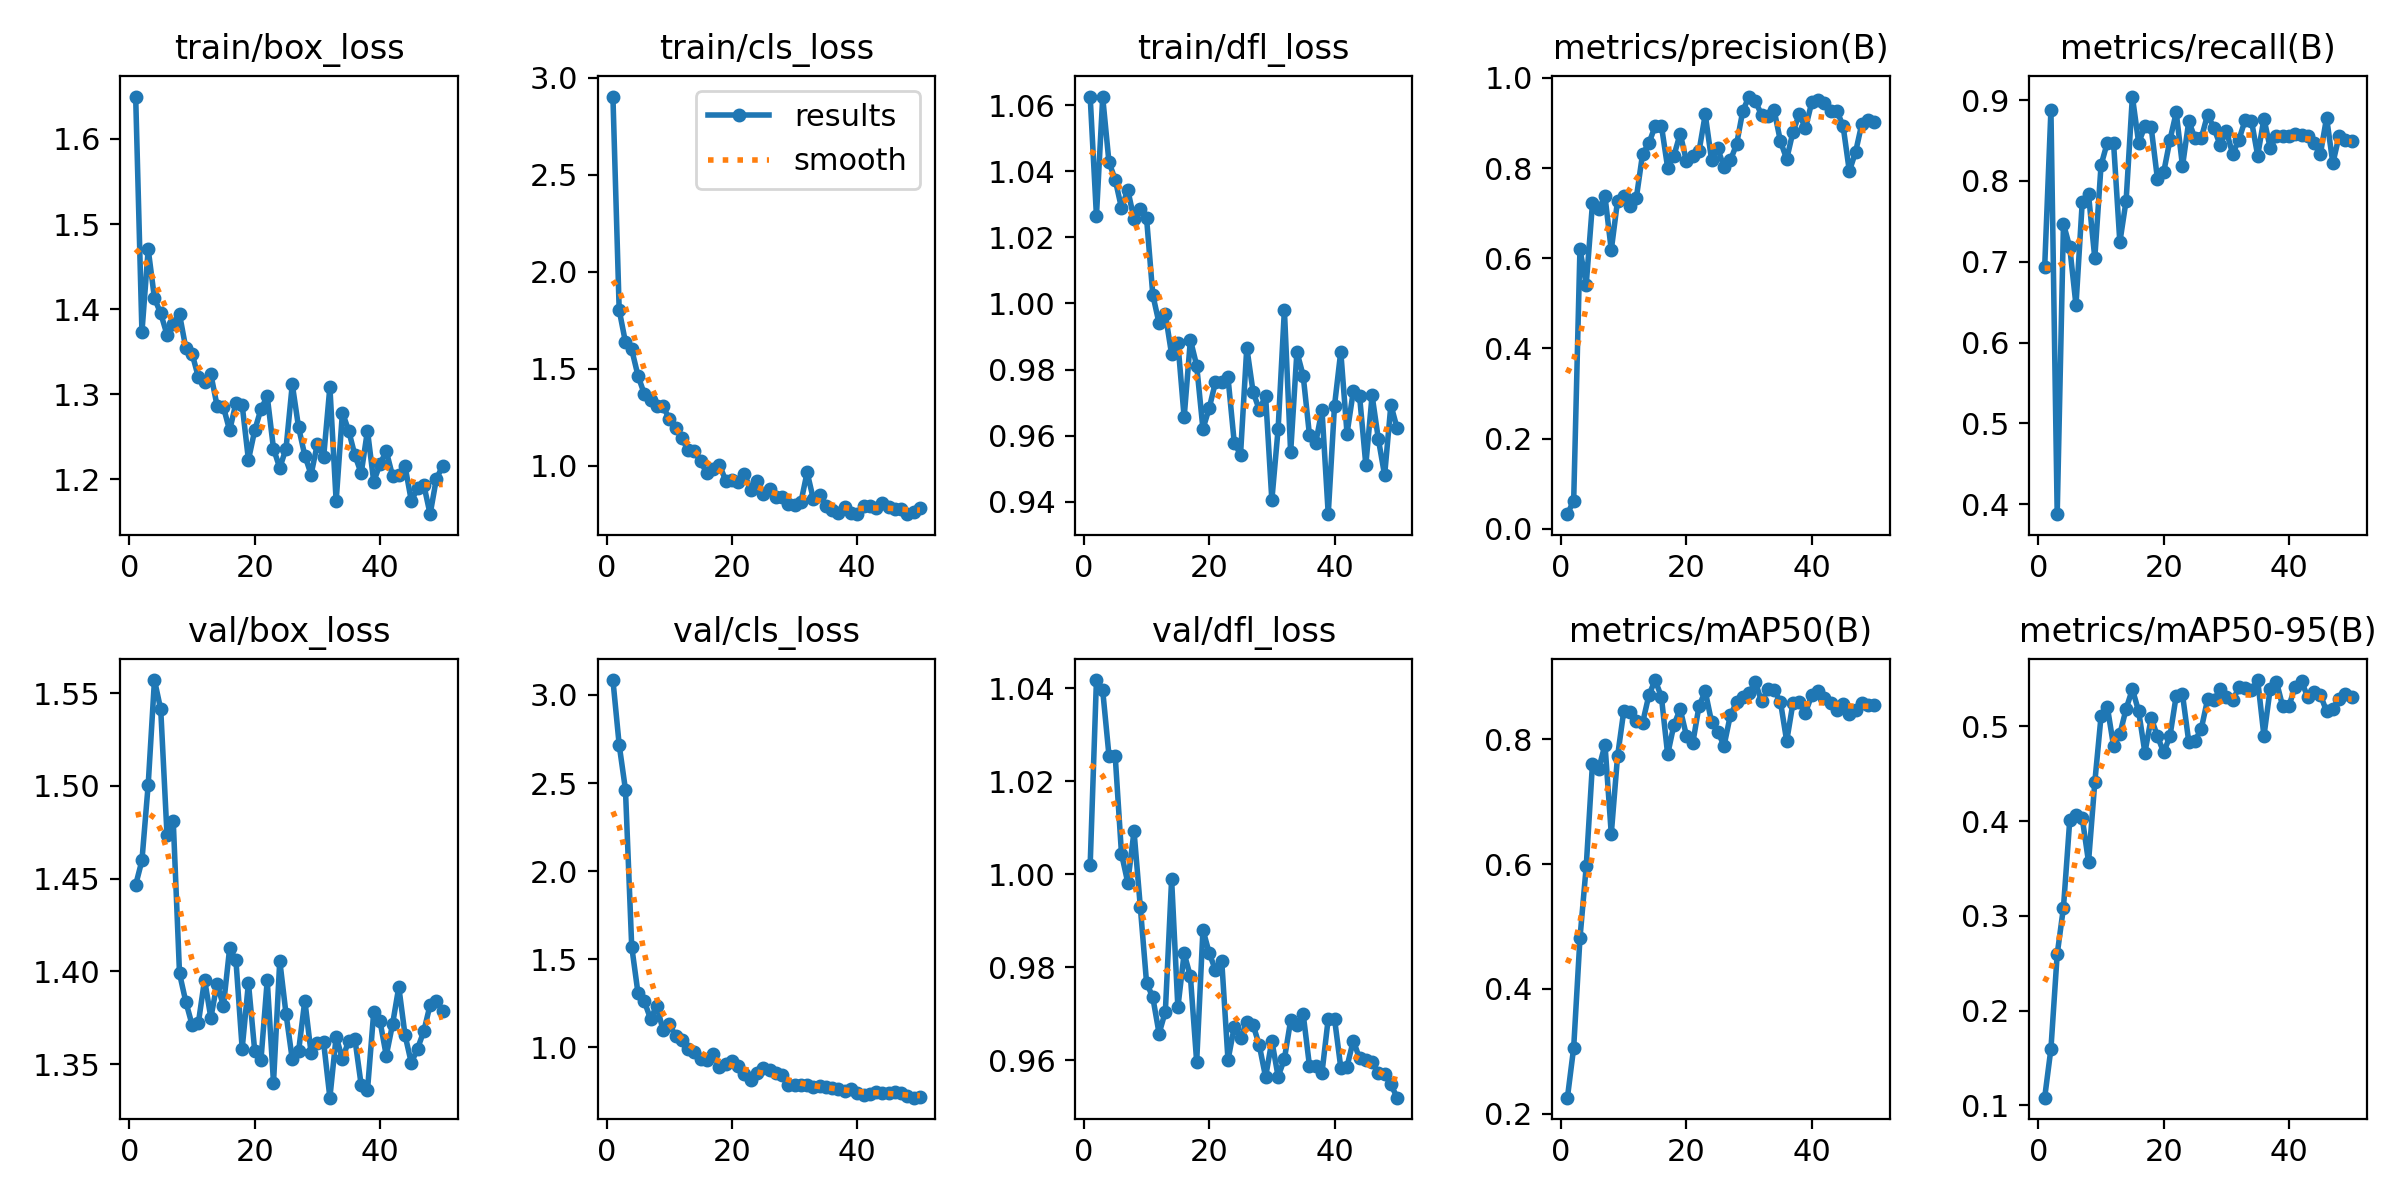

Confusion Matrix
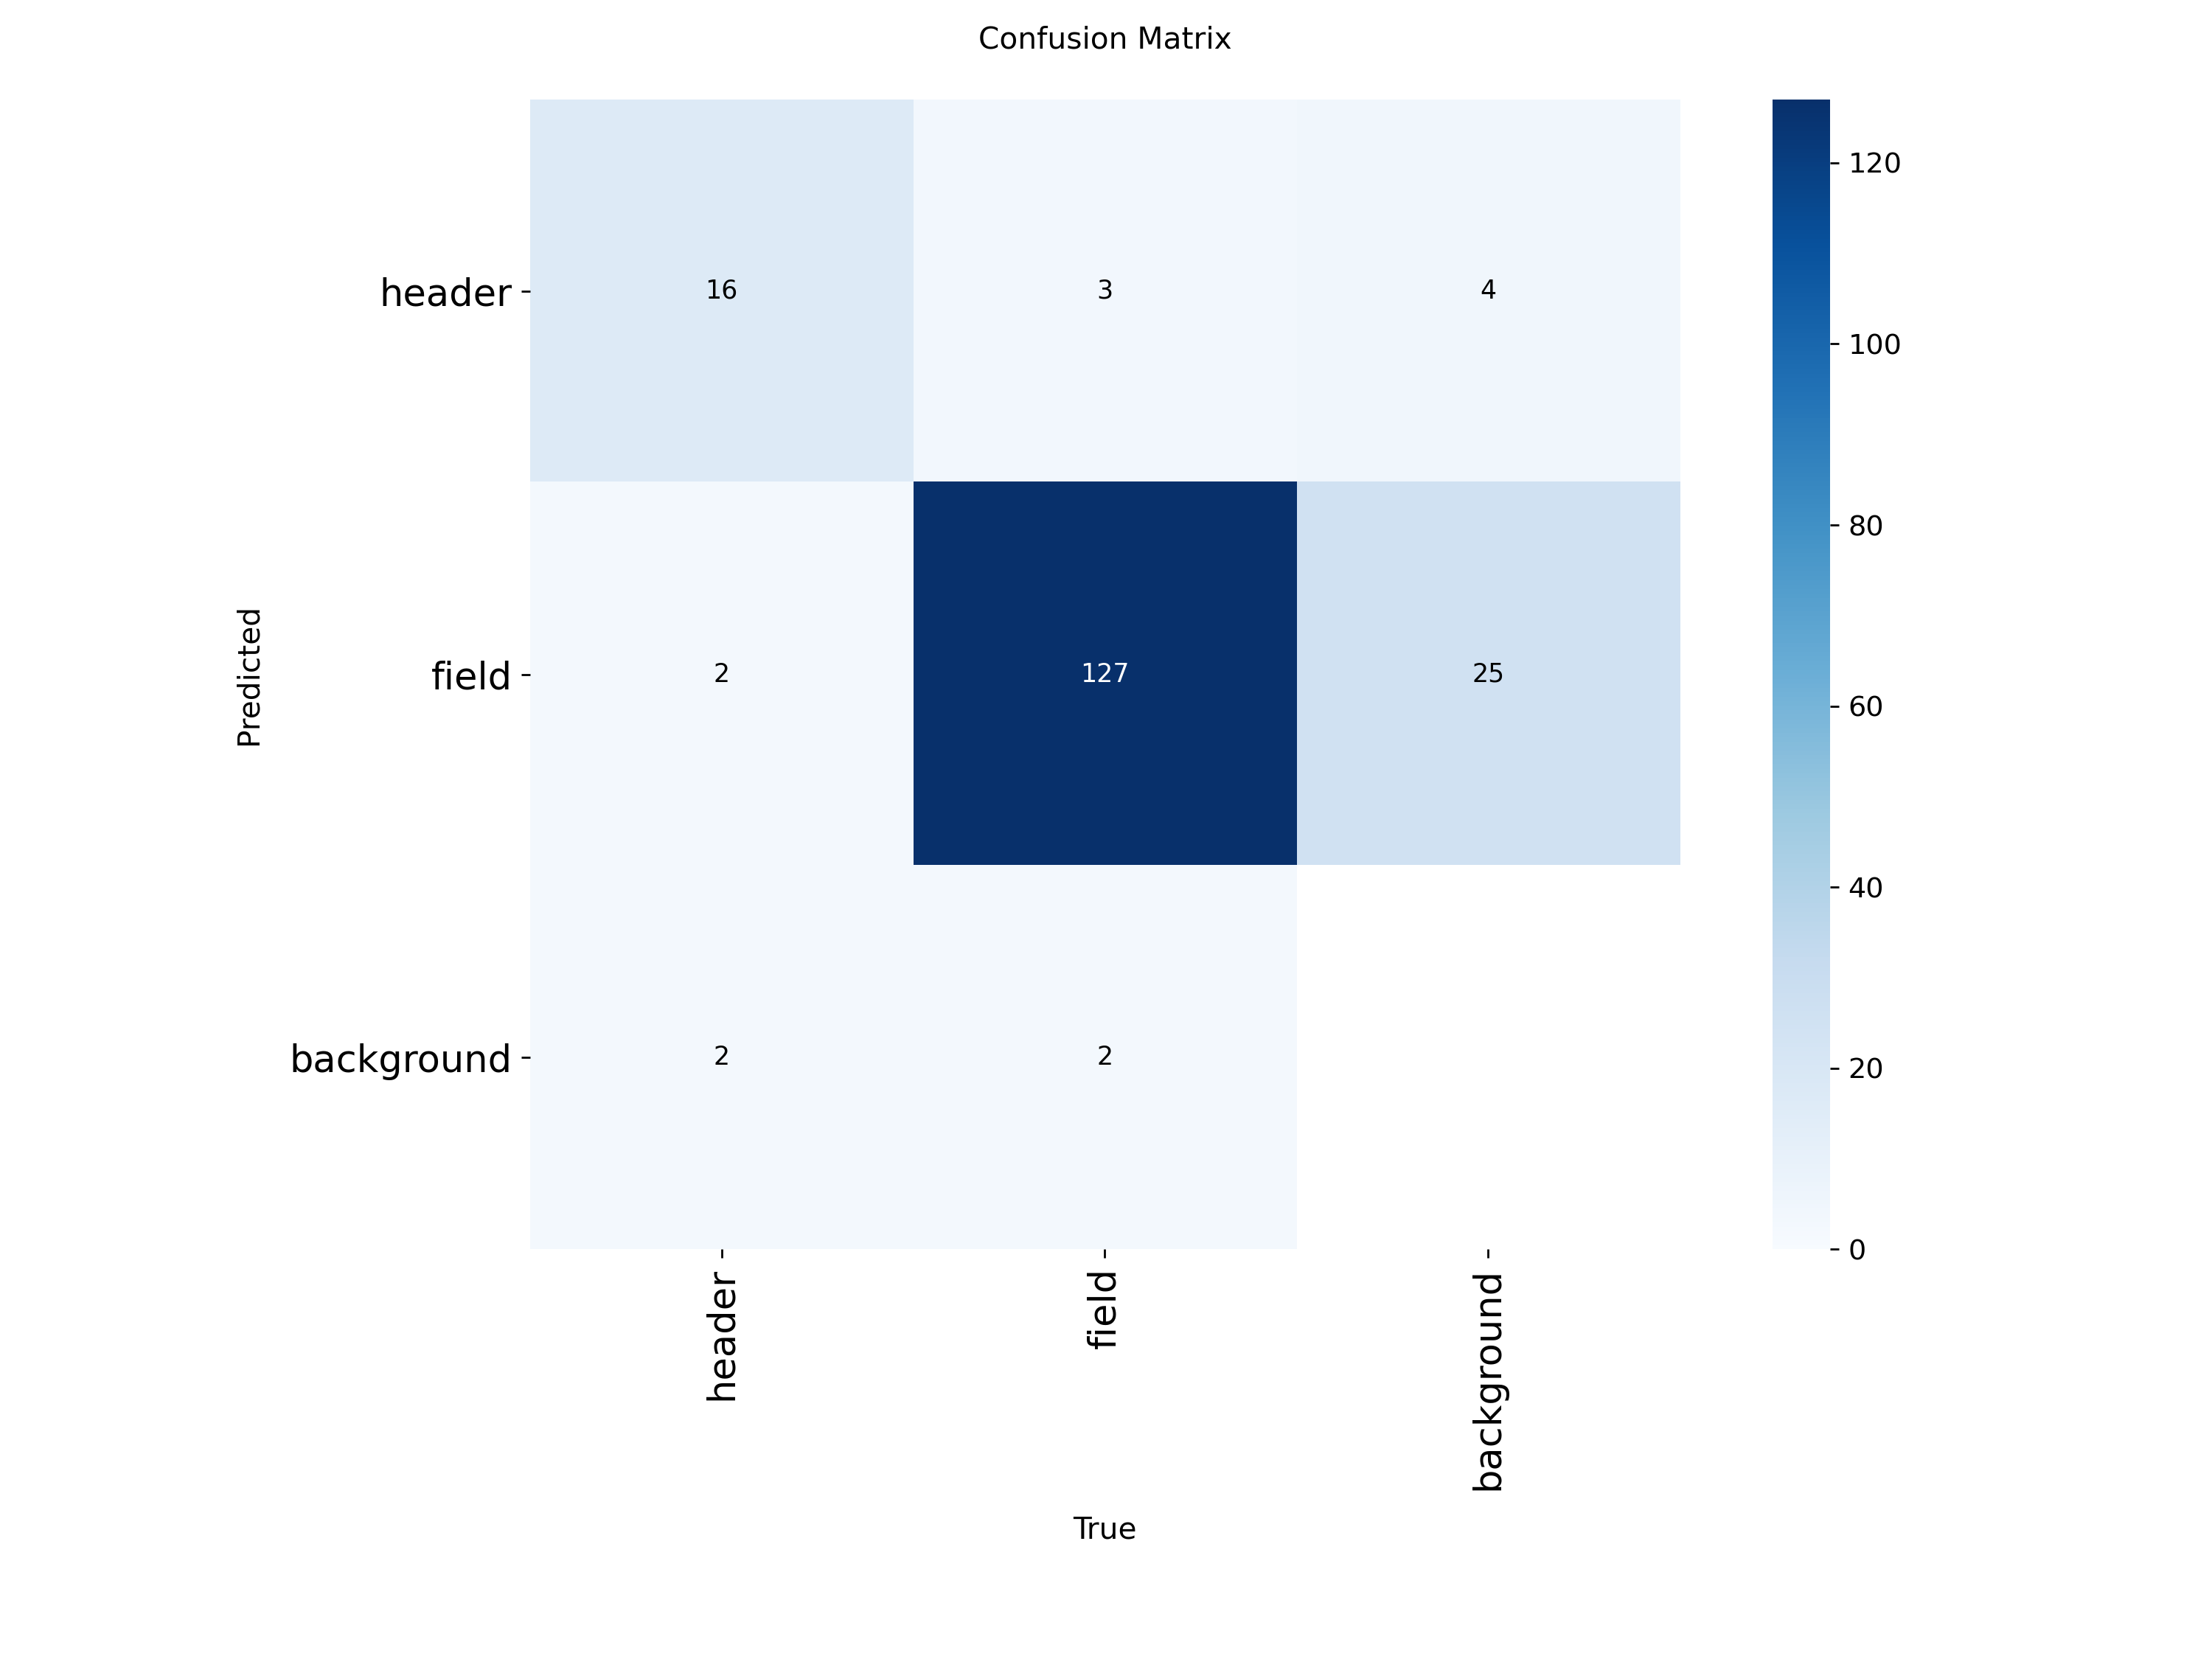